## About the data
This dataset contains recipe-level information from a food site, capturing both nutritional values and traffic performance. Each entry includes calories, carbohydrates, sugar, protein, category type (e.g., Potato, Breakfast, Meat, Dessert), serving size, and whether the recipe attracted high traffic. In essence, it combines nutrition metrics with user engagement data, making it useful for analyzing which recipe categories and serving sizes drive popularity while also comparing their nutritional profiles. 
### ==========================================
### 1. Data Validation: Describe validation and cleaning steps for every column in the data 

Our data contains 947 rows and 8 columns before cleaning and validataion. I have validated all the columns against the criteria in the dataset table:

### ==========================================

In [1]:
#importing relevant libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#read recipe_site_traffic.csv file and convert it into dataframe
df = pd.read_csv("recipe_traffic.csv")

#checking first 5 rows of the dataframe
df.head()

,recipe,calories,carbohydrate,sugar,protein,category,servings,high_traffic
0,1,NaN,NaN,NaN,NaN,Pork,6,High
1,2,35.48,38.56,0.66,0.92,Potato,4,High
2,3,914.28,42.68,3.09,2.88,Breakfast,1,NaN
3,4,97.03,30.56,38.63,0.02,Beverages,4,High
4,5,27.05,1.85,0.80,0.53,Beverages,4,NaN


In [3]:
df = df.drop(['recipe'], axis=1)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 947 entries, 0 to 946
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   calories      895 non-null    float64
 1   carbohydrate  895 non-null    float64
 2   sugar         895 non-null    float64
 3   protein       895 non-null    float64
 4   category      947 non-null    object 
 5   servings      947 non-null    object 
 6   high_traffic  574 non-null    object 
dtypes: float64(4), object(3)
memory usage: 51.9+ KB


In [5]:
df.duplicated().sum()

23

In [6]:
df.isnull().mean()*100
# df['protein'].unique()
# df['protein'].value_counts()

calories         5.491024
carbohydrate     5.491024
sugar            5.491024
protein          5.491024
category         0.000000
servings         0.000000
high_traffic    39.387540
dtype: float64

#### Fixing the servings Column


In [7]:
#checking the values of servings column
df['servings'].value_counts()

4               389
6               197
2               183
1               175
4 as a snack      2
6 as a snack      1
Name: servings, dtype: int64

In [8]:
#replacing the rows including "as a snack" with their relevant numeric number
df['servings']=df['servings'].str.replace(" as a snack", "")

#checking the values of servings column again
df['servings'].value_counts()

4    391
6    198
2    183
1    175
Name: servings, dtype: int64

#### Fixing the high_traffic Column

In [9]:
df['high_traffic'].unique()
# df['high_traffic'].value_counts()

array(['High', nan], dtype=object)

The high traffic variable is the target variable. It has only one value which is "High" so this obvious the missing values in that case are the low traffic data so I will fill the missing values with "Low"

In [10]:
df['high_traffic'].fillna("Low",inplace=True)
df['high_traffic'].value_counts()

High    574
Low     373
Name: high_traffic, dtype: int64

#### Fixing the category Column

In [11]:
#checking the values of category column
df['category'].value_counts()

Breakfast         106
Chicken Breast     98
Beverages          92
Lunch/Snacks       89
Potato             88
Pork               84
Vegetable          83
Dessert            83
Meat               79
Chicken            74
One Dish Meal      71
Name: category, dtype: int64

In [12]:
#replacing chicken Breast with chicken, because chicken Breast is a part of chicken.
df['category'] = df['category'].str.replace(" Breast", "")

#checking the values of servings column again
df['category'].value_counts()

Chicken          172
Breakfast        106
Beverages         92
Lunch/Snacks      89
Potato            88
Pork              84
Vegetable         83
Dessert           83
Meat              79
One Dish Meal     71
Name: category, dtype: int64

In [13]:
#checking missing numbers for each columns
df.isna().mean()*100

calories        5.491024
carbohydrate    5.491024
sugar           5.491024
protein         5.491024
category        0.000000
servings        0.000000
high_traffic    0.000000
dtype: float64

In [14]:
#dropping missing values
df.dropna(inplace=True)
df.isnull().mean()*100

calories        0.0
carbohydrate    0.0
sugar           0.0
protein         0.0
category        0.0
servings        0.0
high_traffic    0.0
dtype: float64

In [15]:
#generating descriptive statistic for each columns
df.describe()

,calories,carbohydrate,sugar,protein
count,895.000000,895.000000,895.000000,895.000000
mean,435.939196,35.069676,9.046547,24.149296
std,453.020997,43.949032,14.679176,36.369739
min,0.140000,0.030000,0.010000,0.000000
25%,110.430000,8.375000,1.690000,3.195000
50%,288.550000,21.480000,4.550000,10.800000
75%,597.650000,44.965000,9.800000,30.200000
max,3633.160000,530.420000,148.750000,363.360000


### ==========================================
### 2. Exploratory Analysis Visualizations
### ==========================================

#### i. Identifying outliers

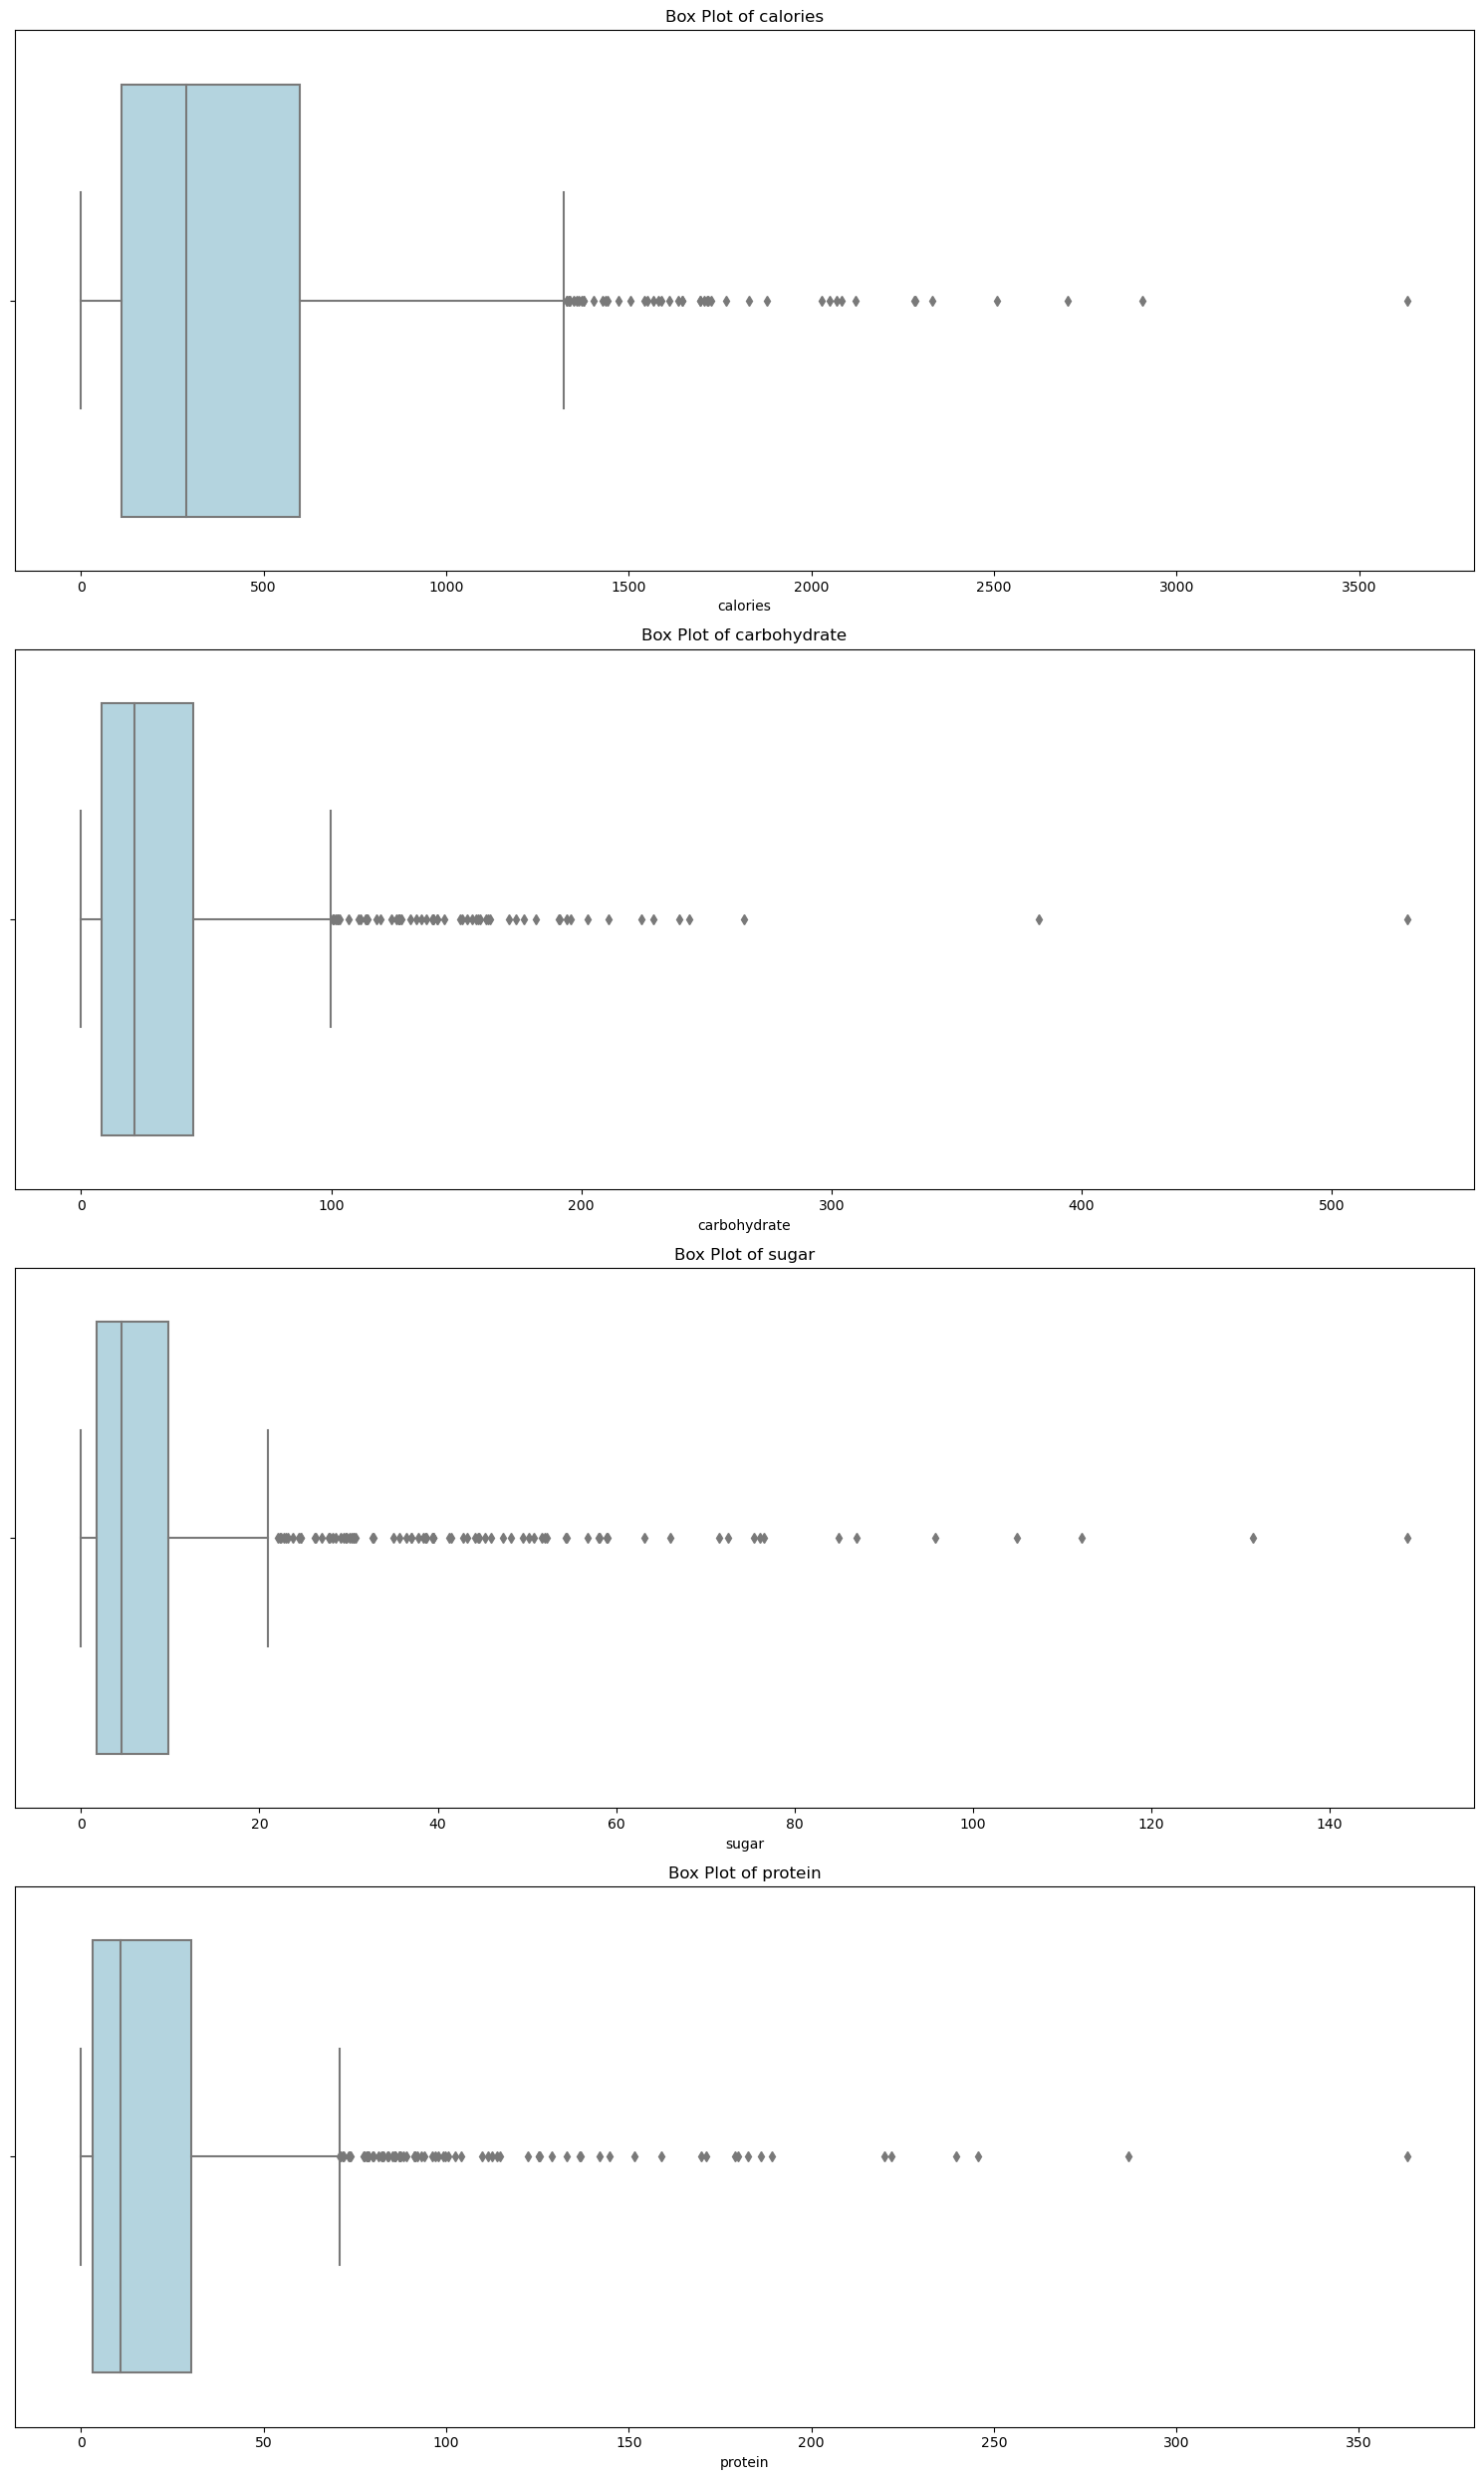

In [16]:
numeric_columns = df.select_dtypes(include=['float64']).columns
plt.figure(figsize=(15, 25))

#iterating over each column and create a bar plot
for i,col in enumerate(numeric_columns):
    plt.subplot(4, 1, i+1)
    sns.boxplot(x=df[col], color='lightblue')
    plt.title(f"Box Plot of {col}")
    plt.xlabel(col)
 
plt.tight_layout()    
plt.show()

##### Remove outliers

In [17]:
print("Original shape:", df.shape)
# Select numerical columns
numeric_columns = df.select_dtypes(include=['float64']).columns

# Function to remove outliers using IQR
def remove_outliers(data, cols):
    for col in cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_limit = Q1 - 1.5 * IQR
        upper_limit = Q3 + 1.5 * IQR
        data = data[(data[col] >= lower_limit) & (data[col] <= upper_limit)]
    return data

# Apply function
df = remove_outliers(df, numeric_columns)

print("After removing outliers:", df.shape)
df_cleaned_data = df.copy()

# Save cleaned dataset if needed
# df.to_csv("cleaned_data.csv", index=False)


Original shape: (895, 7)
After removing outliers: (662, 7)


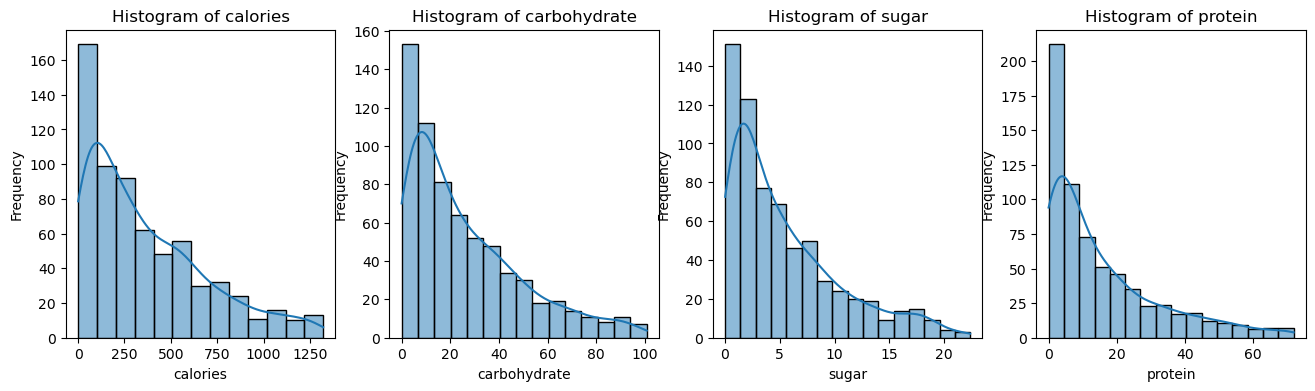

In [18]:
numeric_columns = df.select_dtypes(include=['float64']).columns
plt.figure(figsize=(16, 4))

#iterating over each column and create a bar plot
for i, column in enumerate(numeric_columns):
    plt.subplot(1, len(numeric_columns), i+1)
    sns.histplot(data=df, x=column, kde=True)
    plt.title(f"Histogram of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    
plt.show()

#### ii. Assessing skewness

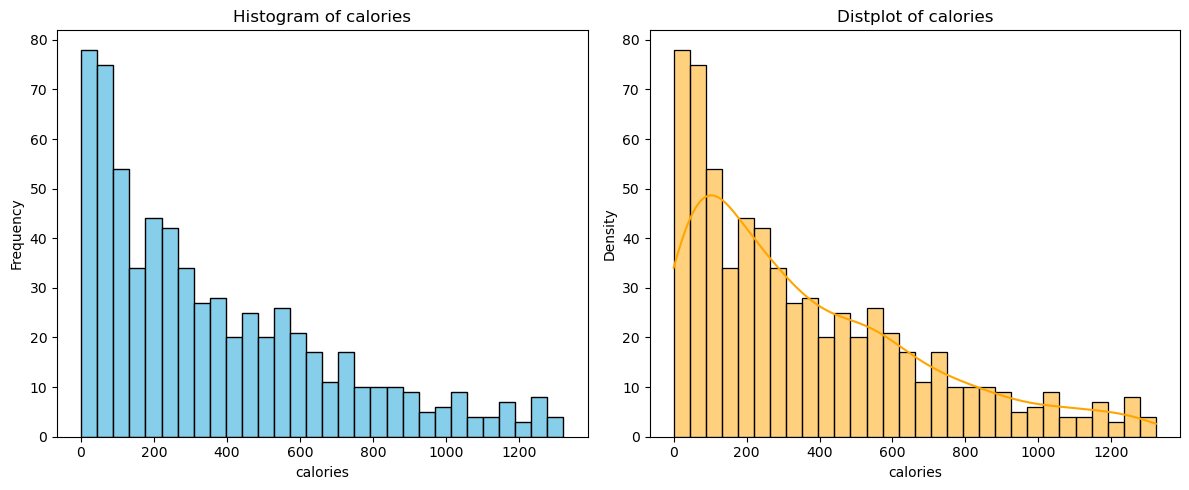

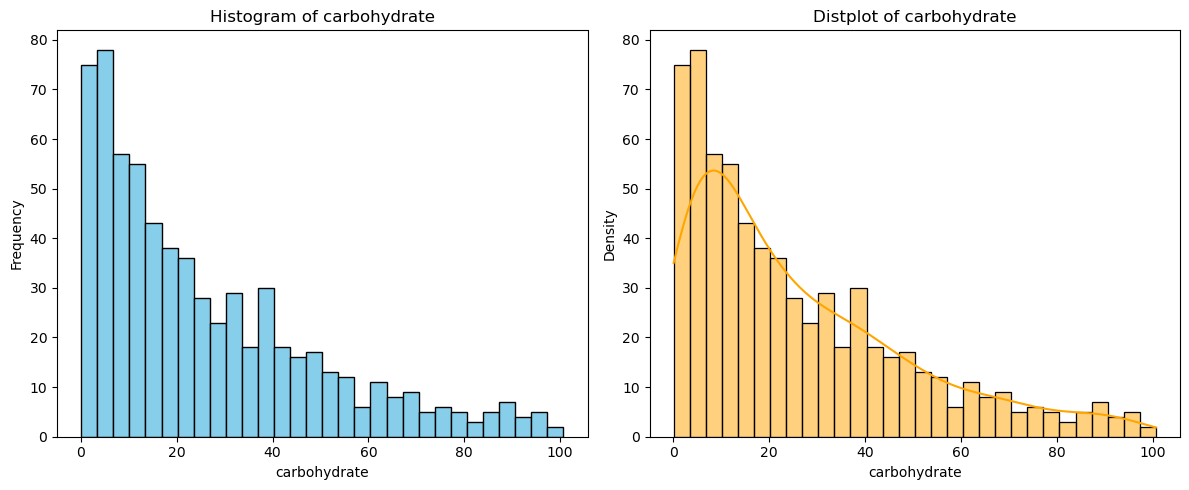

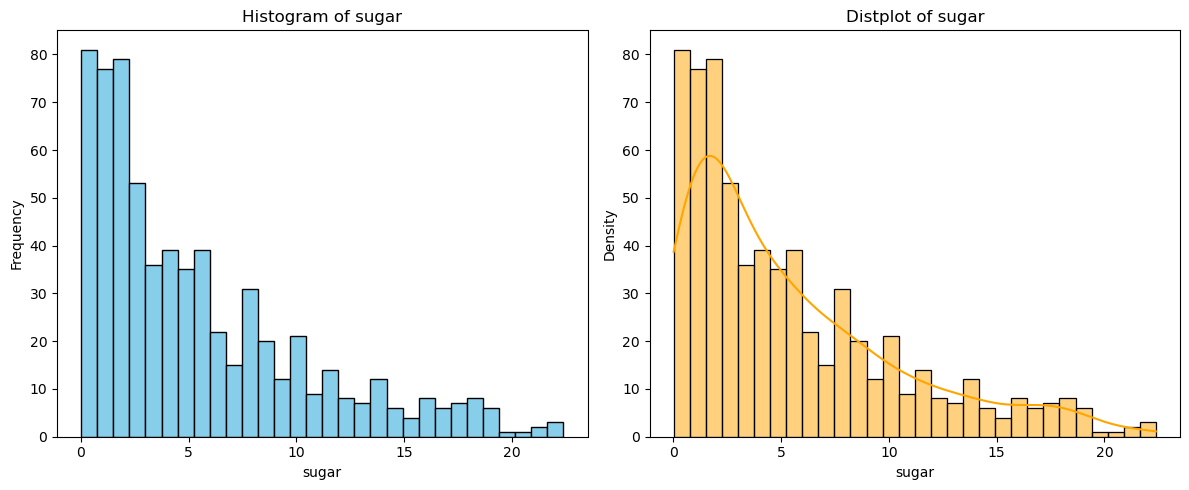

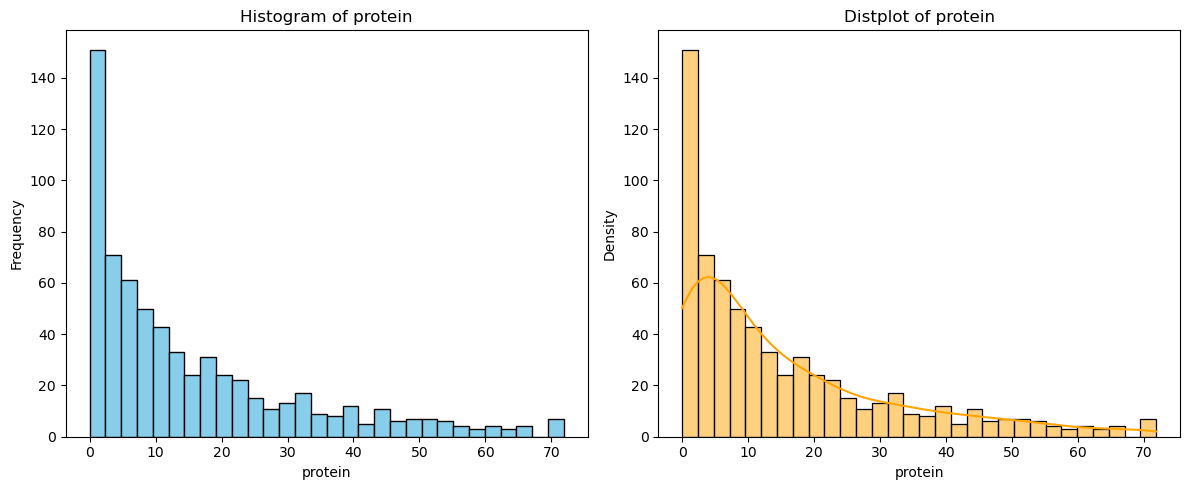

In [19]:
# Select numerical columns
numeric_columns = df.select_dtypes(include=['float64']).columns

# Plot histogram and distplot for each numerical column
for col in numeric_columns:
    plt.figure(figsize=(12,5))
    
    # Histogram
    plt.subplot(1,2,1)
    plt.hist(df[col], bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Histogram of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    
    # Distplot (distribution plot with KDE)
    plt.subplot(1,2,2)
    sns.histplot(df[col], kde=True, bins=30, color='orange')
    plt.title(f"Distplot of {col}")
    plt.xlabel(col)
    plt.ylabel("Density")
    
    plt.tight_layout()
    plt.show()

##### Numerical Data are left-skewed

In order to understand the distribution of the numerical features in our dataset, I used distplot function from seaborn library. This function allows us to visualize the distribution of a given numerical feature by plotting a histogram and fitting a kernel density estimate (KDE) on top of it.

By using distplot to visualize the distribution of calories, carbohydrate, sugar and protein, I found that all of them are left skewed. This means that the majority of the values are concentrated on the left side of the distribution and there are fewer values on the right side.

This information is important because it can affect the performance of our models. Left skewness can cause issues with certain statistical tests and models, such as logistic regression, that assume a normal distribution of data. It also indicates that there might be outliers in the data that could have a significant impact on the results of our analysis. Therefore, it is important to keep this skewness in mind when building our models and to consider appropriate preprocessing techniques to address it.

#### iii. Examining correlation between features

              calories  carbohydrate     sugar   protein
calories      1.000000      0.019104 -0.032164  0.176153
carbohydrate  0.019104      1.000000 -0.031539  0.002039
sugar        -0.032164     -0.031539  1.000000 -0.078286
protein       0.176153      0.002039 -0.078286  1.000000


Text(0.5, 1.0, 'Correlation Heatmap')

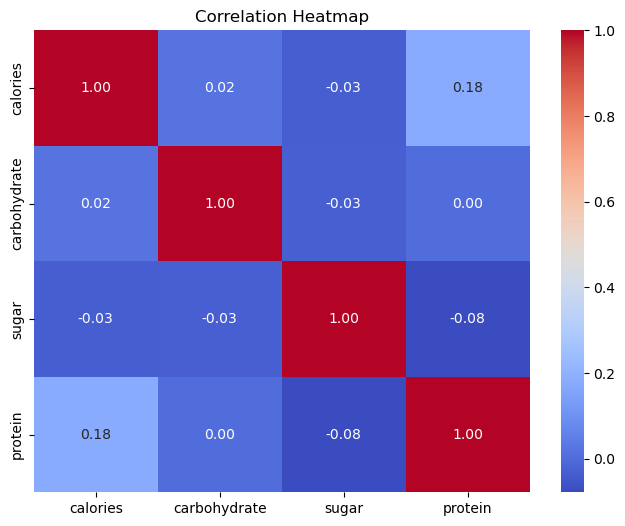

In [20]:
corr=df[['calories', 'carbohydrate', 'sugar', 'protein']].corr()
print(corr)
# Plot using Seaborn's heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")

No correlation

We can see that there is a relatively weak correlation between the features, with the highest correlation coefficient being 0.17 for the relationship between calories and protein. This suggests that there is not a strong linear relationship between any of the features.

#### iv. Distribution of Recipe Traffic

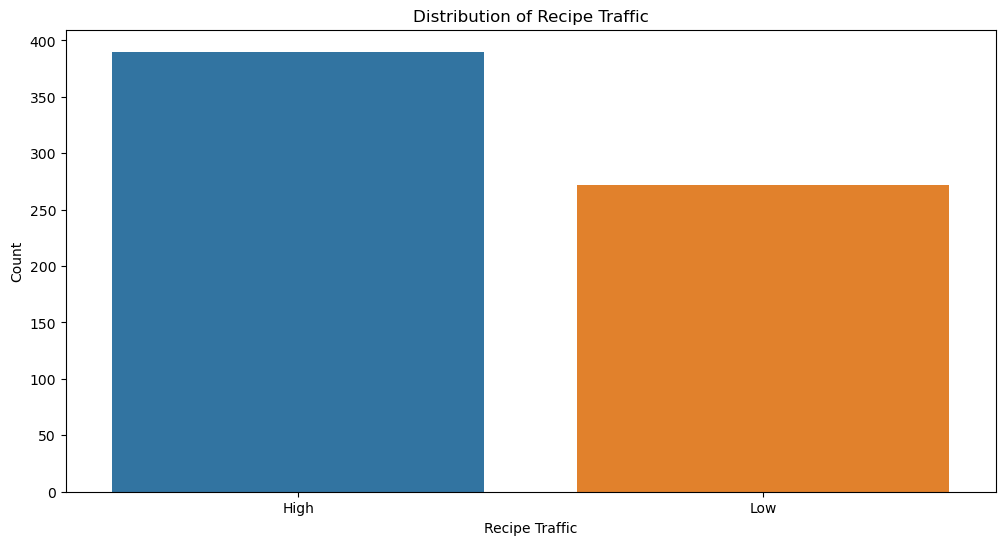

In [21]:
#create a count plot of Traffic
plt.figure(figsize=(12, 6))
sns.countplot(x="high_traffic",data=df)
plt.xlabel("Recipe Traffic")
plt.ylabel("Count")
plt.title("Distribution of Recipe Traffic")
plt.show()

#### v. The relationship between servings and high traffic status.

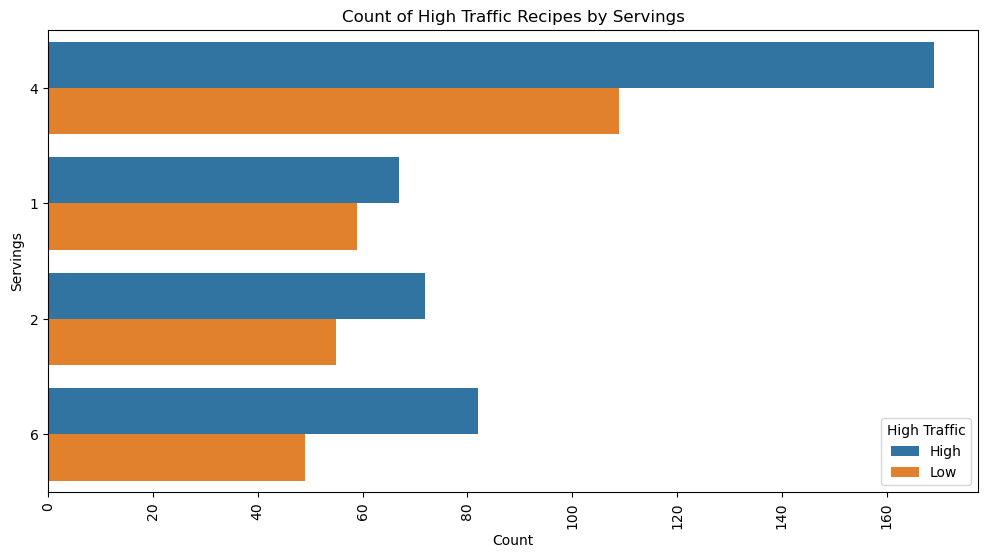

In [22]:
#create a count plot
plt.figure(figsize=(12, 6))
sns.countplot(y="servings", hue="high_traffic", data=df)
plt.xlabel("Count")
plt.ylabel("Servings")
plt.title("Count of High Traffic Recipes by Servings")

#set x axis ticks
plt.xticks(rotation=90)

#set legend title
plt.legend(title="High Traffic")
plt.show()

This graph reveals that recipes designed for medium-sized groups, particularly those serving 4 people, attract the highest traffic, making them the most popular among users. Recipes with 6 servings also perform well, though slightly less than the 4-serving ones, suggesting that larger family-style portions are appealing but not as dominant. In contrast, recipes with smaller portions 1 or 2 servings receive much lower traffic, indicating limited interest in single or couple-sized meals. Overall, the insight is that users tend to prefer recipes that cater to families or small groups, with 4-serving recipes being the sweet spot for engagement.

#### vi. The relationship between categories and high traffic status.

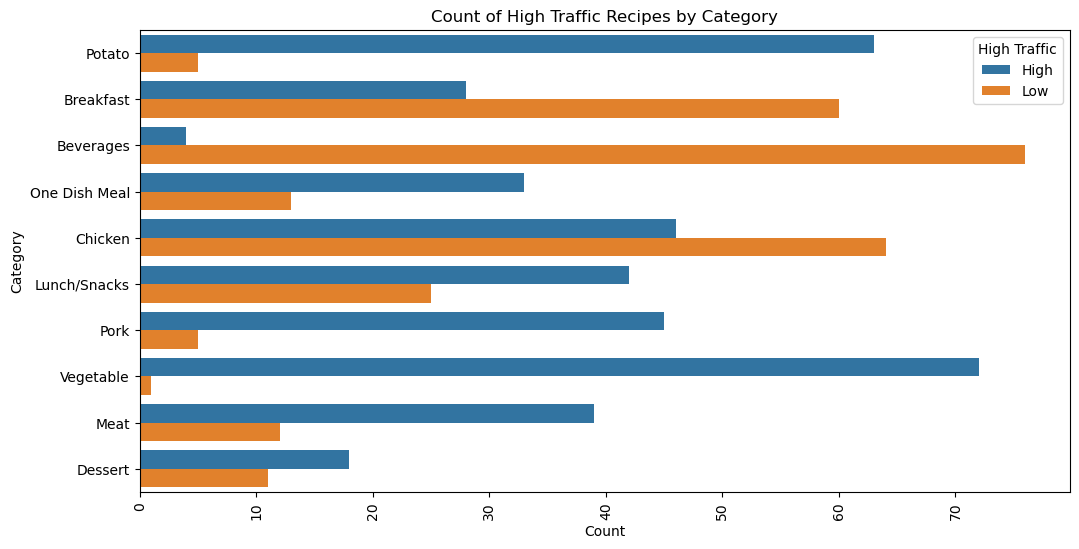

In [23]:
# The relationship between categories and high traffic status
plt.figure(figsize=(12, 6))
sns.countplot(y="category", hue="high_traffic", data=df)
plt.xlabel("Count")
plt.ylabel("Category")
plt.title("Count of High Traffic Recipes by Category")

#set x axis ticks
plt.xticks(rotation=90)

#set legend title
plt.legend(title="High Traffic")
plt.show()

The graph highlights clear differences in recipe traffic across categories. Vegetable and Potato recipes stand out as the most popular, attracting the highest counts of high-traffic engagement, suggesting strong user interest in healthier or versatile food options. In contrast, Beverages and Chicken recipes show a predominance of low-traffic counts, indicating limited audience attention or lower demand in these areas. Categories like Breakfast, One Dish Meal, and Dessert display a more balanced mix, reflecting moderate but steady interest. Overall, the insight is that users gravitate most toward vegetable-based and potato recipes, while beverage and chicken categories struggle to capture high traffic, pointing to potential opportunities for improvement or innovation in those segments.

#### vii. The relationship between categories and their Nutrients.

C:\Users\hp\AppData\Local\Temp\ipykernel_6204\1086061215.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="category", y=column, estimator="mean", ci=None)
C:\Users\hp\AppData\Local\Temp\ipykernel_6204\1086061215.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="category", y=column, estimator="mean", ci=None)
C:\Users\hp\AppData\Local\Temp\ipykernel_6204\1086061215.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="category", y=column, estimator="mean", ci=None)
C:\Users\hp\AppData\Local\Temp\ipykernel_6204\1086061215.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x="category", y=column, estimator="mean", ci=None)


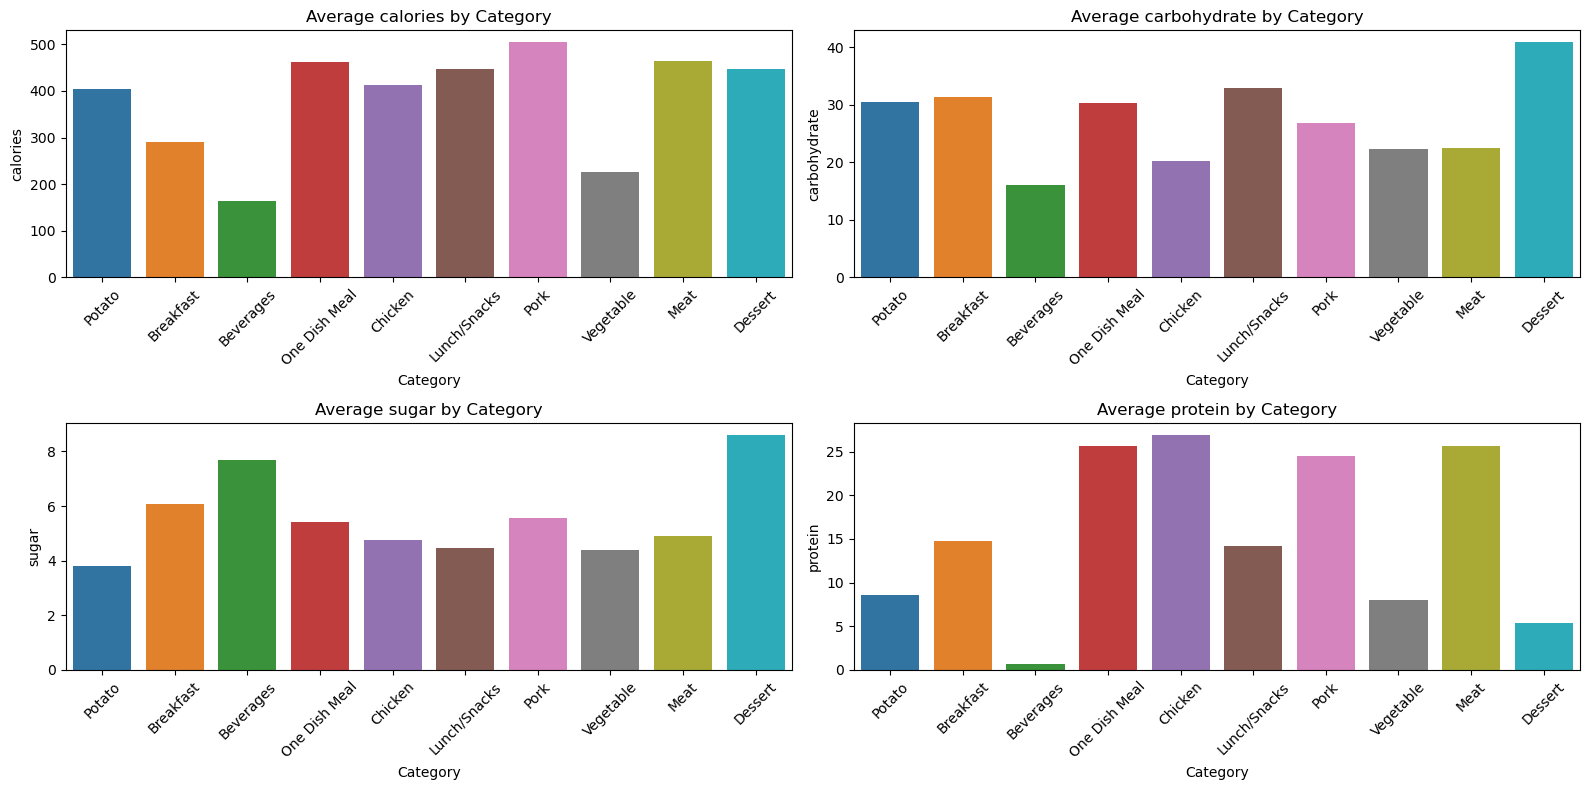

In [24]:
numeric_columns = df.select_dtypes(include=['float64']).columns
plt.figure(figsize=(16, 8))

#iterating over each column and create a bar plot
for i,column in enumerate(numeric_columns):
    plt.subplot(2, 2, i+1)
    sns.barplot(data=df, x="category", y=column, estimator="mean", ci=None)
    plt.xticks(rotation=45)
    plt.title(f"Average {column} by Category")
    plt.xlabel("Category")
    plt.ylabel(column)
 
plt.tight_layout()    
plt.show()

The graphs provide a clear picture of how nutritional values vary across food categories. Dessert recipes stand out with the highest averages for calories, carbohydrates, and sugar, reflecting their indulgent nature. Beverages also show high sugar and carbohydrate levels, though with relatively lower calories compared to desserts. On the other hand, Meat, Chicken, and Pork categories dominate in protein content, making them strong sources of nutrition for those seeking high-protein meals. Vegetables and Potatoes, while lower in protein, offer moderate calories and carbohydrates, positioning them as balanced options. Overall, the insight is that desserts and beverages are the most calorie- and sugar-dense categories, while meats provide the richest protein content, highlighting a clear divide between indulgent and nutrient-focused recipe types.

### ==========================================
### 3. Model Development
### ==========================================

In [25]:
#split the data into features (x) and target variable (y)
x = df.drop("high_traffic", axis=1)
y = df["high_traffic"]

In [26]:

from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Encode target feature (High/Low → 1/0)
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

# Identify float and categorical columns
float_cols = x.select_dtypes(include=['float64']).columns
cat_cols = x.select_dtypes(include=['object']).columns
# Define preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("scaler", StandardScaler(), float_cols),
        ("onehot", OneHotEncoder(drop="first"), cat_cols)
    ]
)

In [27]:
from sklearn.model_selection import train_test_split

#split the data into training and testing sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=7)

In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [29]:
lrc = LogisticRegression(max_iter=1000)
svc = SVC(kernel='sigmoid', gamma=1.0)
knc = KNeighborsClassifier()
dtc = DecisionTreeClassifier(max_depth=5)
rfc = RandomForestClassifier(n_estimators=200, random_state=42)
abc = AdaBoostClassifier(n_estimators=200, random_state=42)
bc = BaggingClassifier(n_estimators=200, random_state=42)
etc = ExtraTreesClassifier(n_estimators=200, random_state=42)
gbc = GradientBoostingClassifier(n_estimators=200, random_state=42)
xgb = XGBClassifier(n_estimators=200, random_state=42)

clfs = {'LR': lrc, 'SVC' : svc, 'KN' : knc,'DT': dtc, 'RF': rfc, 'AdaBoost': abc, 'BgC': bc, 'ETC': etc,'GBC':gbc,'XGB':xgb}

### ==========================================
### 4. Model evaluation
### ==========================================

#### Check Accuracy
The accuracy of these models was evaluated using several performance metrics, including **accuracy_score, precision_score, recall_score, F1-score, and confusion_matrix**.

In [30]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
def get_metrics(clf,x_train,y_train,x_test,y_test):
    pipe=Pipeline([('step1',preprocessor),('step2',clf)])
    pipe.fit(x_train,y_train)
    y_pred = pipe.predict(x_test)
    
    
    accuracy = accuracy_score(y_test,y_pred)
    precision = precision_score(y_test,y_pred)
    recall = recall_score(y_test,y_pred)
    f1 = f1_score(y_test,y_pred)
    confusion = confusion_matrix(y_test,y_pred)
    
    return accuracy, precision, recall, f1, confusion

In [31]:
accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []
confusion_matrices= []

for name,clf in clfs.items():
    
    current_accuracy, current_precision, current_recall, current_f1, current_confusion = get_metrics(clf,x_train,y_train,x_test,y_test)
    
    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    recall_scores.append(current_recall)
    f1_scores.append(current_f1)
    confusion_matrices.append(current_confusion)
    
metrics_df = pd.DataFrame({'Algorithm':clfs.keys(),'accuracy_scores':accuracy_scores,'precision_scores':precision_scores,'recall_scores':recall_scores, 'f1_scores':f1_scores, 'confusion_matrices':confusion_matrices})
metrics_df

,Algorithm,accuracy_scores,precision_scores,recall_scores,f1_scores,confusion_matrices
0,LR,0.736842,0.650000,0.735849,0.690265,"[[59, 21], [14, 39]]"
1,SVC,0.511278,0.403226,0.471698,0.434783,"[[43, 37], [28, 25]]"
2,KN,0.684211,0.596491,0.641509,0.618182,"[[57, 23], [19, 34]]"
3,DT,0.706767,0.652174,0.566038,0.606061,"[[64, 16], [23, 30]]"
4,RF,0.721805,0.666667,0.603774,0.633663,"[[64, 16], [21, 32]]"
5,AdaBoost,0.736842,0.645161,0.754717,0.695652,"[[58, 22], [13, 40]]"
6,BgC,0.699248,0.638298,0.566038,0.600000,"[[63, 17], [23, 30]]"
7,ETC,0.714286,0.653061,0.603774,0.627451,"[[63, 17], [21, 32]]"
8,GBC,0.669173,0.581818,0.603774,0.592593,"[[57, 23], [21, 32]]"
9,XGB,0.661654,0.576923,0.566038,0.571429,"[[58, 22], [23, 30]]"


#### Models comparision
Looking at the table, Logistic Regression (LR) is the baseline model with an accuracy of 0.7368 and an F1-score of 0.6903. To identify the best models, we need to compare accuracy, precision, recall, and F1-score, since each metric highlights different strengths. Accuracy alone can be misleading if class imbalance exists, so F1-score is often the most balanced measure.

Among all models, AdaBoost stands out with the highest recall (0.7547) and the highest F1-score (0.6957), slightly outperforming Logistic Regression. This suggests AdaBoost is particularly strong at correctly identifying positive cases, which is crucial in many classification problems. Logistic Regression, while slightly lower in recall, maintains competitive precision and overall balanced performance. Together, these two models provide the most reliable results compared to others.

Other models such as Random Forest (RF) and Extra Trees Classifier (ETC) show reasonable accuracy and precision but do not surpass LR and AdaBoost in terms of F1-score. Models like SVC and XGB perform poorly across most metrics, making them less suitable for deployment in this scenario.

##### Final Conclusion:  
The two best models are Logistic Regression (baseline) and AdaBoost, as they deliver the strongest balance of accuracy, precision, recall, and F1-score. Logistic Regression provides a stable and interpretable baseline, while AdaBoost enhances recall and overall F1-score, making it slightly superior. For practical deployment, AdaBoost would be the preferred choice if maximizing detection of positive cases is critical, while Logistic Regression remains a solid, simpler alternative.

#### Our Selected Model

In [32]:
from sklearn.ensemble import AdaBoostClassifier
abc_model = AdaBoostClassifier(n_estimators=200, random_state=42)
pipe=Pipeline([('step1',preprocessor),('step2',abc_model)])
pipe.fit(x_train,y_train)

Pipeline(steps=[('step1',
                 ColumnTransformer(transformers=[('scaler', StandardScaler(),
                                                  Index(['calories', 'carbohydrate', 'sugar', 'protein'], dtype='object')),
                                                 ('onehot',
                                                  OneHotEncoder(drop='first'),
                                                  Index(['category', 'servings'], dtype='object'))])),
                ('step2',
                 AdaBoostClassifier(n_estimators=200, random_state=42))])

#### Prediction System

In [33]:
# Input data as dictionary with column names
input_data = {
    'calories': 300.05,
    'carbohydrate': 1.67,
    'sugar': 1.10,
    'protein': 39.11,
    'category': 'Potato',
    'servings': '6'
}

# Convert to DataFrame (1 row, with column names)
input_df = pd.DataFrame([input_data])

# Predict using pipeline
prediction = pipe.predict(input_df)

# Output result
if prediction[0] == 1:
    print('High Traffic')
else:
    print("Low Traffic")


Low Traffic


### ==========================================
### 5. Final Summary and Recommendations


#### Final Summary

This project focused on building machine learning models to predict whether a recipe would generate high traffic. Several classification algorithms were tested, including Logistic Regression, Decision Tree, Random Forest, AdaBoost, Bagging, Gradient Boosting, and XGBoost. Logistic Regression was used as the baseline model, while AdaBoost and Random Forest emerged as the strongest models after comparison. Among all models, AdaBoost provided the best balance between identifying high-traffic recipes and maintaining overall prediction quality.

#### Recommendations:
Based on these findings, the business should adopt the **AdaBoost model** for predicting high-traffic recipes and use it as a decision-support tool for content promotion. Recipes predicted as high traffic can be prioritized on the homepage, marketing campaigns, or recommendation systems to improve customer engagement and increase website visits. The company should also continue collecting more recipe and traffic data because additional high-quality data can further improve model performance over time. Regular monitoring of recall and F1-score should be performed to ensure the model continues to identify high-traffic recipes effectively.

### ==========================================